Завдання лабораторної роботи
Мета роботи:
Навчитися аналізувати часові ряди, визначати їх компоненти, будувати прогностичні моделі та оцінювати їх точність.
Етапи виконання:
1.	Вибір фактору для прогнозу:
o	На основі набору даних з першої чи другої лабораторної роботи виберіть один довільний фактор (показник), який потрібно прогнозувати.

In [1]:
import pandas as pd

#Loading file as dataframe
file_path = 'global_food_prices.csv'
df = pd.read_csv(file_path)

pd.set_option('display.max_colwidth', None) 
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)  

# Display the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

/var/folders/p5/jffj9yld09n0wvq85zzz5y7r0000gn/T/ipykernel_97006/1578192751.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


First 5 rows of the dataset:
   adm0_id    adm0_name  adm1_id   adm1_name  mkt_id  mkt_name  cm_id         cm_name  cur_id cur_name  pt_id pt_name  um_id um_name  mp_month  mp_year  mp_price  mp_commoditysource
0      1.0  Afghanistan      272  Badakhshan     266  Fayzabad     55  Bread - Retail     0.0      AFN     15  Retail      5      KG         1     2014      50.0                 NaN
1      1.0  Afghanistan      272  Badakhshan     266  Fayzabad     55  Bread - Retail     0.0      AFN     15  Retail      5      KG         2     2014      50.0                 NaN
2      1.0  Afghanistan      272  Badakhshan     266  Fayzabad     55  Bread - Retail     0.0      AFN     15  Retail      5      KG         3     2014      50.0                 NaN
3      1.0  Afghanistan      272  Badakhshan     266  Fayzabad     55  Bread - Retail     0.0      AFN     15  Retail      5      KG         4     2014      50.0                 NaN
4      1.0  Afghanistan      272  Badakhshan     266  Fayzaba

In [2]:
print(df['cm_name'].unique())


['Bread - Retail' 'Wheat - Retail' 'Rice (low quality) - Retail'
 'Wage (qualified labour) - Retail'
 'Livestock (sheep, one-year-old alive female) - Retail'
 'Fuel (diesel) - Retail' 'Exchange rate - Retail'
 'Wage (non-qualified labour, non-agricultural) - Retail'
 'Oil (cooking) - Retail' 'Sugar - Retail' 'Pulses - Retail'
 'Wheat flour (high quality) - Retail' 'Salt - Retail'
 'Rice (high quality) - Retail' 'Wheat flour (low quality) - Retail'
 'Wheat flour - Retail' 'Rice - Retail' 'Beans (white) - Retail'
 'Milk - Retail' 'Potatoes - Retail' 'Eggs - Retail'
 'Meat (chicken) - Retail' 'Lentils - Retail' 'Pasta - Retail'
 'Tomatoes - Retail' 'Oil - Retail' 'Meat (beef) - Retail'
 'Cheese (dry) - Retail' 'Carrots - Retail' 'Onions - Retail'
 'Bananas - Retail' 'Tea - Retail' 'Fuel (petrol-gasoline) - Retail'
 'Fish (canned) - Retail' 'Apples - Retail' 'Oranges - Retail'
 'Milk (camel) - Retail' 'Meat (camel) - Retail' 'Tea (sahm) - Retail'
 'Oil (palm) - Retail' 'Cassava flour - Ret

In [4]:
# Обраний товар
selected_product = 'Wheat - Retail'
selected_country = 'Afghanistan'

# Фільтрація по товару та країні
df_product = df[(df['cm_name'] == selected_product) & (df['adm0_name'] == selected_country)]

# Пошук регіону з найбільшою кількістю записів
top_region = df_product['adm1_name'].value_counts().idxmax()
print(f"Обраний регіон з найбільшою кількістю записів: {top_region}")

# Остаточна фільтрація по регіону
df_filtered = df_product[df_product['adm1_name'] == top_region].copy()

# Формування колонки з датою
df_filtered['date'] = pd.to_datetime(dict(year=df_filtered.mp_year, month=df_filtered.mp_month, day=1))
df_filtered = df_filtered.sort_values('date')

df_filtered = df_filtered.reset_index(drop=True)

# Виведення перших рядків фінального підмноження
print("Вибрані дані для аналізу та прогнозування:")
print(df_filtered[['date', 'mp_price']].head(25))

print(f"Кількість записів після фільтрації: {df_filtered.shape[0]}")



Обраний регіон з найбільшою кількістю записів: Badakhshan
Вибрані дані для аналізу та прогнозування:
         date  mp_price
0  2003-01-01     7.000
1  2003-01-01     7.000
2  2003-02-01     6.000
3  2003-02-01     7.000
4  2003-03-01     7.000
5  2003-03-01     7.000
6  2003-04-01     6.000
7  2003-04-01     7.000
8  2003-05-01     6.000
9  2003-05-01     5.000
10 2003-06-01     7.000
11 2003-06-01     6.000
12 2003-07-01     7.000
13 2003-07-01     7.000
14 2003-08-01     6.525
15 2003-08-01     7.275
16 2003-09-01     6.575
17 2003-09-01     6.775
18 2003-10-01     6.800
19 2003-10-01     7.175
20 2003-11-01     6.800
21 2003-11-01     6.975
22 2003-12-01     6.675
23 2003-12-01     6.225
24 2004-01-01     6.300
Кількість записів після фільтрації: 425


2.	Побудова графіка вибраного фактору:
o	Використовуючи бібліотеки Python (наприклад, matplotlib або seaborn), побудуйте графік обраного фактору.

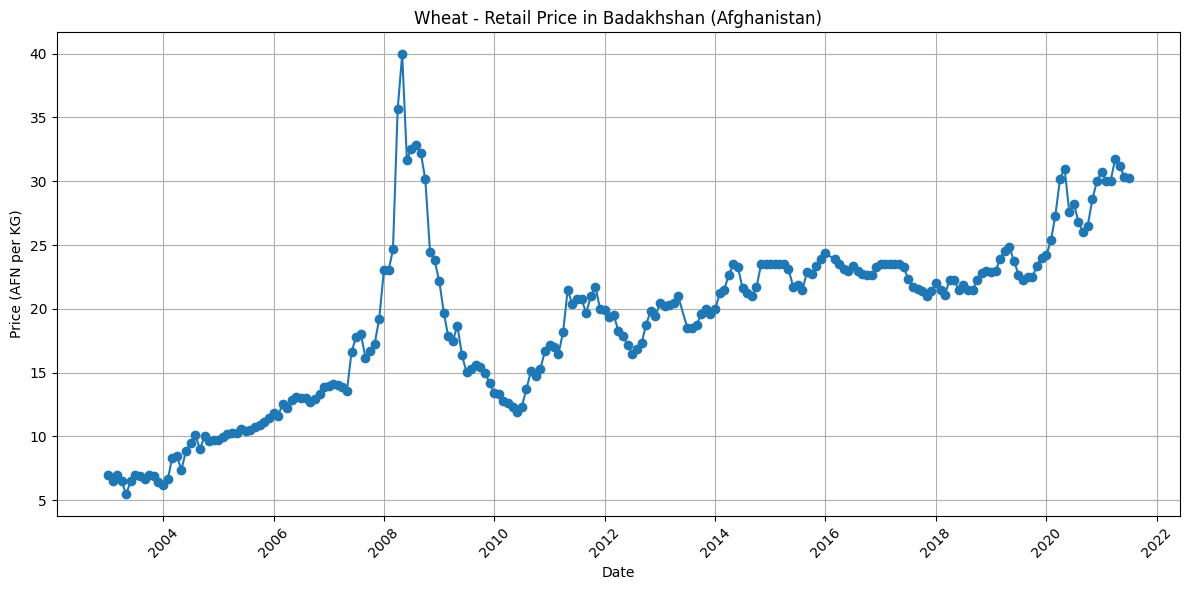

In [5]:
import matplotlib.pyplot as plt

# Якщо ще не було скидання індексу (не обов'язково, але зручно для виводу)
df_filtered = df_filtered.reset_index(drop=True)

# Групуємо дані за датою (беремо середнє, якщо дублікати)
df_grouped = df_filtered.groupby('date')['mp_price'].mean()

# Побудова графіка
plt.figure(figsize=(12, 6))
plt.plot(df_grouped.index, df_grouped.values, marker='o', linestyle='-')
plt.title('Wheat - Retail Price in Badakhshan (Afghanistan)')
plt.xlabel('Date')
plt.ylabel('Price (AFN per KG)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


3.	Розклад фактору на компоненти:

o	Виконайте декомпозицію обраного фактору на трендову, сезонну та випадкову компоненти за допомогою бібліотеки statsmodels.

o	Побудуйте окремі графіки для кожної з компонент.

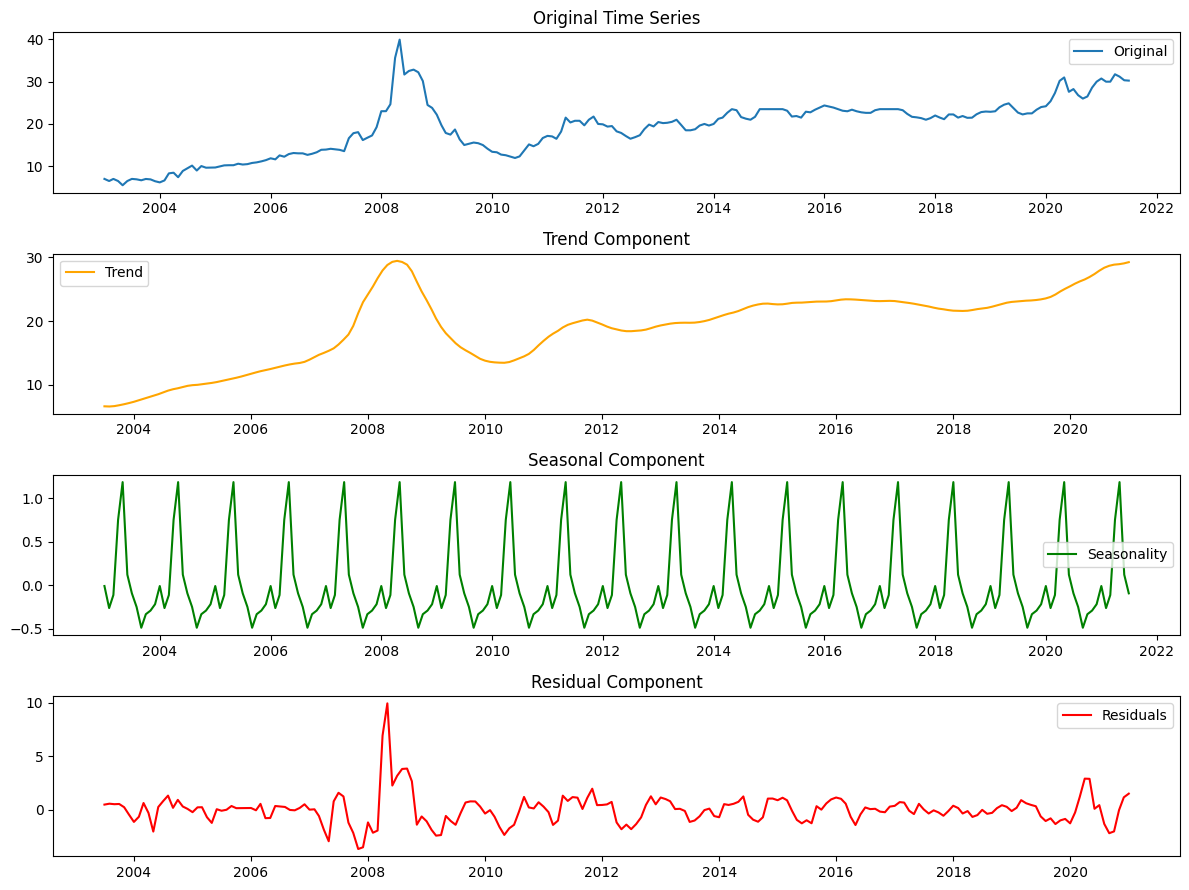

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Формуємо часовий ряд з частотою "MS" (початок кожного місяця)
ts = df_grouped.asfreq('MS')

# Заповнення пропущених значень інтерполяцією (можна також forward fill або dropna)
ts = ts.interpolate()

# Декомпозиція (додаткова модель)
decomposition = seasonal_decompose(ts, model='additive')

# Побудова графіків
plt.figure(figsize=(12, 9))

plt.subplot(411)
plt.plot(ts, label='Original')
plt.title('Original Time Series')
plt.legend()

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.title('Trend Component')
plt.legend()

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.title('Seasonal Component')
plt.legend()

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()

4.	Побудова графіків ACF та PACF:
o	Використовуючи бібліотеку statsmodels, побудуйте графіки автокореляційної функції (ACF) та часткової автокореляційної функції (PACF) для вибраного фактору.

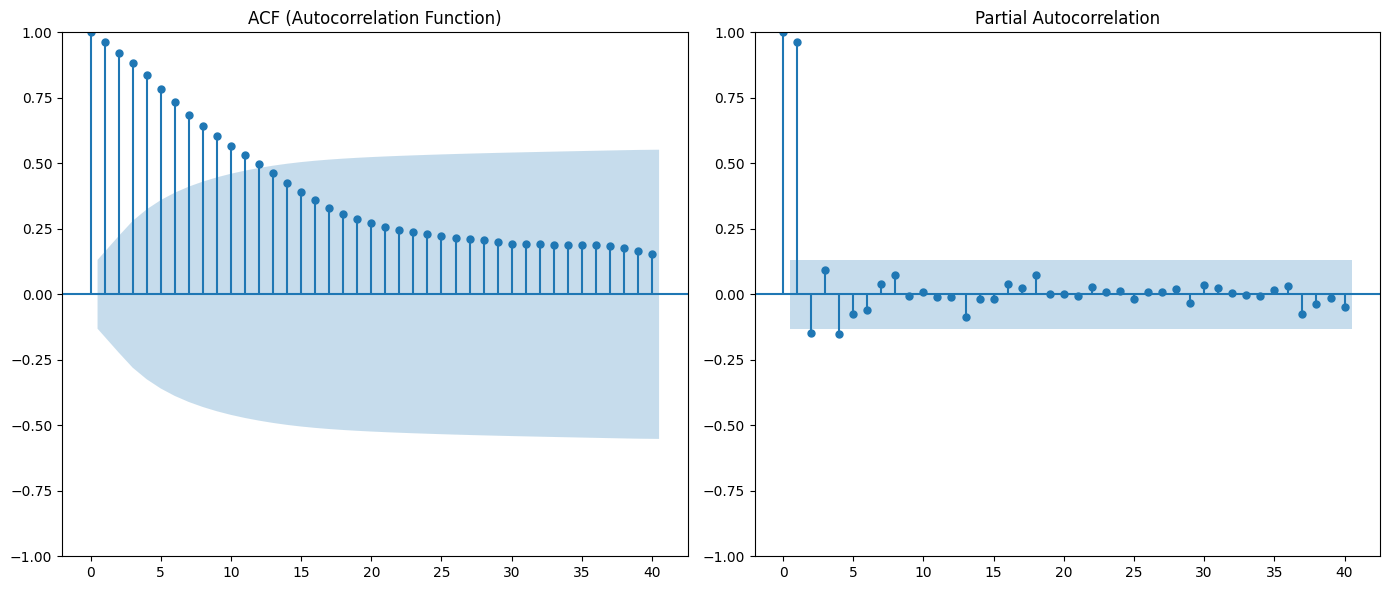

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Візьмемо вже підготовлений ряд: ts = df_grouped.asfreq('MS')
# Ми вже виконували .interpolate() раніше — тож беремо готовий ts

plt.figure(figsize=(14, 6))

# ACF (автокореляційна функція)
plt.subplot(1, 2, 1)
plot_acf(ts, lags=40, ax=plt.gca())
plt.title('ACF (Autocorrelation Function)')

# PACF (часткова автокореляційна функція)
plt.subplot(1, 2, 2)
plot_pacf(ts, lags=40, ax=plt.gca(), method='ywm')  # 'ywm' — стійкий метод

plt.tight_layout()
plt.show()


5.	Побудова моделей прогнозування:
o	Побудуйте наступні моделі прогнозування:
	Модель Holt’s Winters (Triple Exponential Smoothing)


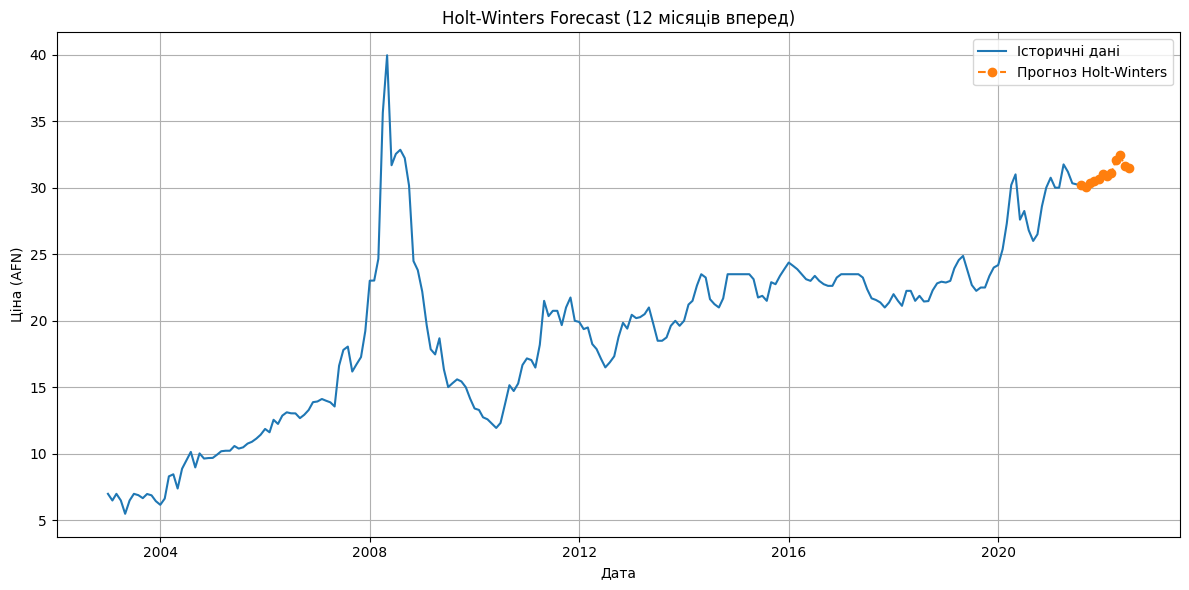

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Побудова моделі Holt-Winters
hw_model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12  # бо це місячні дані, тобто сезонність річна
).fit()

# Прогноз на 12 місяців вперед
forecast_holt = hw_model.forecast(12)

# Побудова графіка
plt.figure(figsize=(12, 6))
plt.plot(ts, label='Історичні дані')
plt.plot(forecast_holt, label='Прогноз Holt-Winters', linestyle='--', marker='o')
plt.title('Holt-Winters Forecast (12 місяців вперед)')
plt.xlabel('Дата')
plt.ylabel('Ціна (AFN)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


	ARIMA (AutoRegressive Integrated Moving Average)


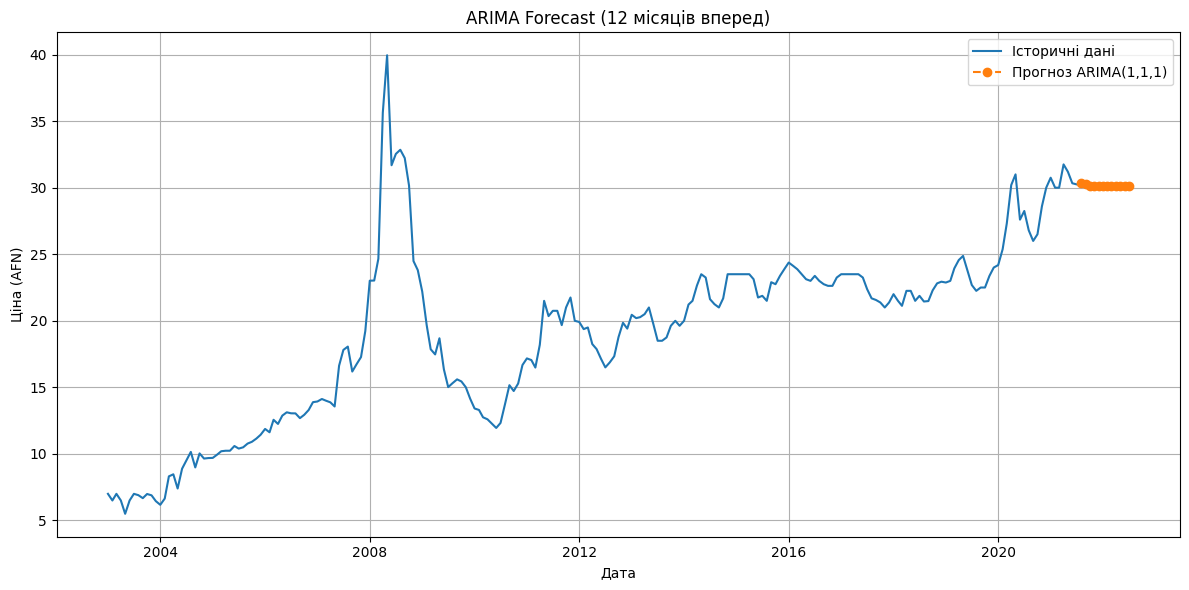

In [17]:
from statsmodels.tsa.arima.model import ARIMA

# Якщо ще не зроблено — інтерпольований місячний ряд:
# ts = df_grouped.asfreq('MS').interpolate()

# Для прикладу візьмемо початкову модель ARIMA(1,1,1)
arima_model = ARIMA(ts, order=(4, 1, 2))  # p=1, d=1, q=1
arima_result = arima_model.fit()

# Прогноз на 12 місяців
forecast_arima = arima_result.forecast(steps=12)

# Побудова графіка
plt.figure(figsize=(12, 6))
plt.plot(ts, label='Історичні дані')
plt.plot(forecast_arima, label='Прогноз ARIMA(1,1,1)', linestyle='--', marker='o')
plt.title('ARIMA Forecast (12 місяців вперед)')
plt.xlabel('Дата')
plt.ylabel('Ціна (AFN)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


	ARCH (Autoregressive Conditional Heteroskedasticity)


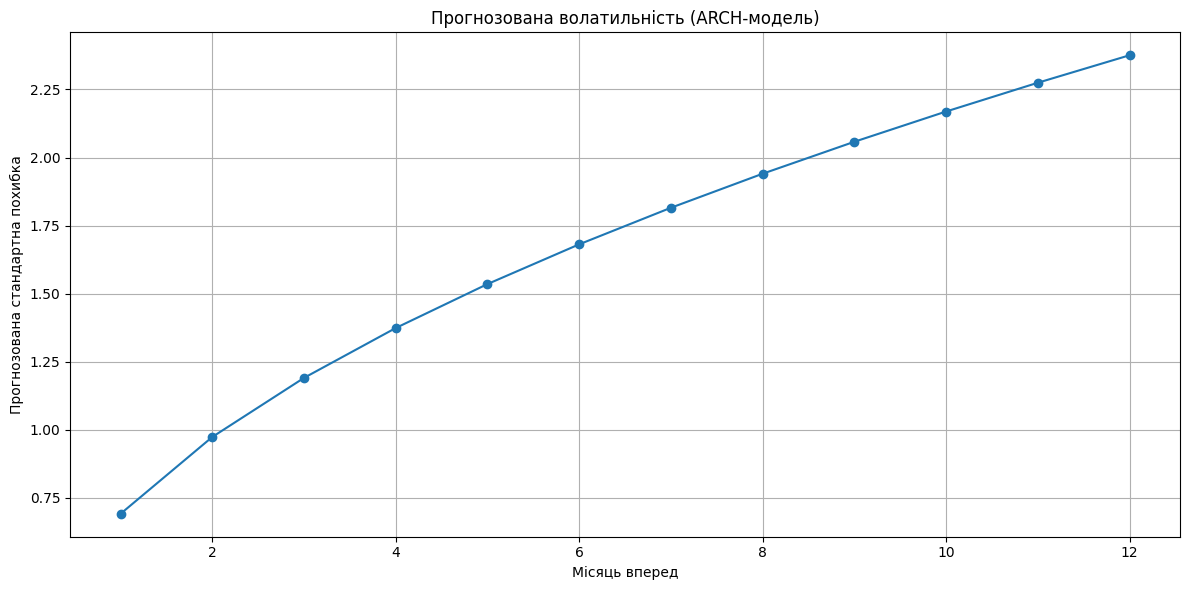

In [10]:
from arch import arch_model
import numpy as np

# Для ARCH модель застосовується до залишків — наприклад, диференційованого ряду
# Якщо ts — це рівень цін, то розраховуємо прирости (returns)
ts_diff = ts.diff().dropna()

# Побудова ARCH(1) моделі
arch_mod = arch_model(ts_diff, vol='ARCH', p=1)
arch_res = arch_mod.fit(disp='off')

# Прогноз волатильності на 12 місяців вперед
forecast_arch = arch_res.forecast(horizon=12)

# Витягуємо умовну дисперсію (волатильність)
predicted_volatility = np.sqrt(forecast_arch.variance.values[-1, :])

# Побудова графіка
plt.figure(figsize=(12, 6))
plt.plot(range(1, 13), predicted_volatility, marker='o')
plt.title('Прогнозована волатильність (ARCH-модель)')
plt.xlabel('Місяць вперед')
plt.ylabel('Прогнозована стандартна похибка')
plt.grid(True)
plt.tight_layout()
plt.show()


o	Використовуйте GridSearchCV для підбору оптимальних параметрів моделей.

In [11]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

p_values = range(0, 3)
d_values = range(0, 2)
q_values = range(0, 3)

best_score = float("inf")
best_order = None
best_model_arima = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(ts, order=(p, d, q))
                model_fit = model.fit()
                aic = model_fit.aic
                if aic < best_score:
                    best_score = aic
                    best_order = (p, d, q)
                    best_model_arima = model_fit
            except:
                continue

print(f"✅ ARIMA best order: {best_order} with AIC: {best_score:.2f}")


✅ ARIMA best order: (0, 1, 2) with AIC: 758.44


In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

trend_options = ['add', 'mul', None]
seasonal_options = ['add', 'mul', None]
seasonal_periods = [12]

best_score = float("inf")
best_config = None
best_model_hw = None

for trend in trend_options:
    for seasonal in seasonal_options:
        if trend is None and seasonal is None:
            continue
        try:
            model = ExponentialSmoothing(ts, trend=trend, seasonal=seasonal, seasonal_periods=12)
            model_fit = model.fit()
            aic = model_fit.aic
            if aic < best_score:
                best_score = aic
                best_config = (trend, seasonal)
                best_model_hw = model_fit
        except:
            continue

print(f"✅ Holt-Winters best config: trend={best_config[0]}, seasonal={best_config[1]}, AIC={best_score:.2f}")


✅ Holt-Winters best config: trend=None, seasonal=mul, AIC=130.21


In [20]:
from arch import arch_model
import numpy as np

# ts_diff — попередньо обрахований приріст: ts.diff().dropna()
ts_diff = ts.diff().dropna()

best_score = float("inf")
best_p = None
best_model_arch = None

for p in range(1, 6):  # ARCH(1) до ARCH(5)
    try:
        model = arch_model(ts_diff, vol='ARCH', p=p)
        model_fit = model.fit(disp='off')
        aic = model_fit.aic
        if aic < best_score:
            best_score = aic
            best_p = p
            best_model_arch = model_fit
    except:
        continue

print(f"✅ ARCH best p: {best_p} with AIC: {best_score:.2f}")


✅ ARCH best p: 5 with AIC: 616.71


6.	Побудова графіків прогнозів:
o	Побудуйте графіки прогнозів для кожної з моделей та порівняйте їх між собою.

In [21]:
ts = df_grouped.asfreq('MS').interpolate()

forecast_arima = best_model_arima.forecast(steps=12)

forecast_hw = best_model_hw.forecast(12)

forecast_arch = best_model_arch.forecast(horizon=12)
predicted_volatility = np.sqrt(forecast_arch.variance.values[-1, :])

arch_base = ts.iloc[-1]
arch_upper = arch_base + predicted_volatility
arch_lower = arch_base - predicted_volatility


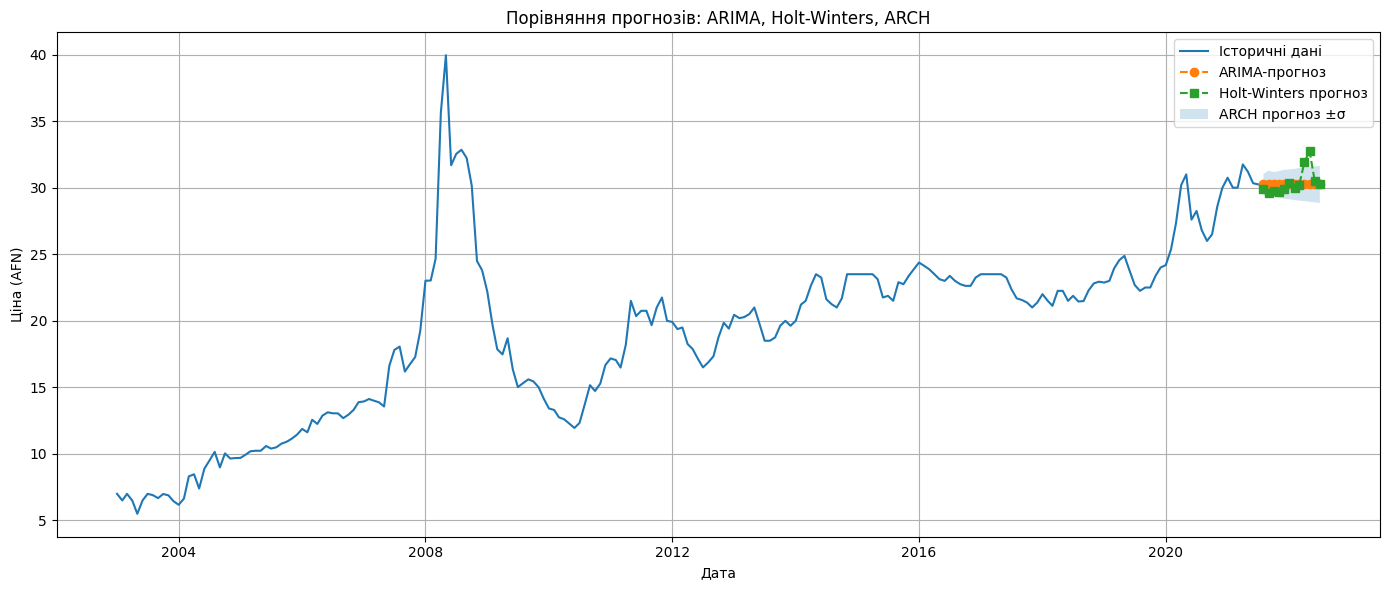

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Створимо індекс прогнозу
future_index = pd.date_range(ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

plt.figure(figsize=(14, 6))

# Базовий часо́вий ряд
plt.plot(ts, label='Історичні дані')

# ARIMA
plt.plot(future_index, forecast_arima, label='ARIMA-прогноз', linestyle='--', marker='o')

# Holt-Winters
plt.plot(future_index, forecast_hw, label='Holt-Winters прогноз', linestyle='--', marker='s')

# ARCH — візуалізація довіри (±волатильність)
plt.fill_between(future_index, arch_lower, arch_upper, alpha=0.2, label='ARCH прогноз ±σ')

plt.title('Порівняння прогнозів: ARIMA, Holt-Winters, ARCH')
plt.xlabel('Дата')
plt.ylabel('Ціна (AFN)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


7.	Порівняння точності моделей:

o	Порівняйте точність побудованих моделей за допомогою відповідних метрик (наприклад, MSE, RMSE, MAE).

o	Висновок про найбільш точну модель на основі результатів порівняння.

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Розділяємо ts на train/test
train = ts[:-12]
test = ts[-12:]

# 2. ARIMA на train
arima = ARIMA(train, order=best_order).fit()
pred_arima = arima.forecast(steps=12)

# 3. Holt-Winters на train
hw = ExponentialSmoothing(train, trend=best_config[0], seasonal=best_config[1], seasonal_periods=12).fit()
pred_hw = hw.forecast(12)

# 4. ARCH — прогнозуємо волатильність, але не рівень. Для оцінки зробимо на приростах
ts_diff = train.diff().dropna()
arch = arch_model(ts_diff, vol='ARCH', p=best_p).fit(disp='off')
arch_vol = arch.forecast(horizon=12)
# Ми умовно кажемо: прогнозована сер.волатильність навколо останнього train-значення
arch_base = train.iloc[-1]
pred_arch = [arch_base] * 12  # Прогноз рівня — плаский

# 5. Метрики

def evaluate(true, pred, model_name):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    print(f"{model_name}:\n  MSE={mse:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}\n")
    return mse, rmse, mae

print("📊 Оцінка точності моделей по останніх 12 місяцях:")
metrics_arima = evaluate(test, pred_arima, "ARIMA")
metrics_hw = evaluate(test, pred_hw, "Holt-Winters")
metrics_arch = evaluate(test, pred_arch, "ARCH (спрощено)")


📊 Оцінка точності моделей по останніх 12 місяцях:
ARIMA:
  MSE=3.61, RMSE=1.90, MAE=1.71

Holt-Winters:
  MSE=3.26, RMSE=1.81, MAE=1.72

ARCH (спрощено):
  MSE=4.59, RMSE=2.14, MAE=2.01

